# 高息成长池 × MA120 区间触发策略

**策略概览**（代码在 `backtest/band.py`，本 notebook 只做回测与分析）：

- **标的池**: `screener/pool_screener.py` 高息+成长 28 只（季度更新）
- **入场**: 未持有 && 筛选通过 && 收盘 ≤ MA120×(1−12%) → 首买 5%
- **补仓**: 未补过 && 较成本再跌 20% → 追加至 10%
- **卖出**: ≥ MA120×(1+10%) → 清仓
- **资金**: 新买入部分等比缩放至总权重 ≤100%，余下留现金；未触发持仓不动

回测区间 2023-01-01 ~ 2026-07-31，初始资金 50 万，含交易成本。

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'band_ma120.py')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, _ROOT)
from screener.pool import POOL, build_pool_screener, load_qfq, load_raw
from strategy.band_ma120 import BandStrategy
from backtest.metrics import nav_summary as perf_summary
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
START = pd.Timestamp('2023-01-01')
END = pd.Timestamp('2026-07-31')
INITIAL_CAPITAL = 500_000.0

## 1. 数据加载与参数

In [2]:
mkt = {c: load_qfq(c) for c in POOL if load_qfq(c) is not None}
bench_codes = {'000300': '沪深300', '000922': '中证红利'}
for c in bench_codes:
    df = load_raw(c) if c not in mkt else mkt[c]
    if df is None:
        df = load_qfq(c)
    mkt[c] = df
print(f'可用行情标的: {len(mkt)}')
def make_screener():
    return build_pool_screener(div_min=0.03, pe_max=20.0, dev_buy=-0.12)
def bench_nav(code, start=START, end=END):
    df = mkt[code]; df = df[(df.index >= start) & (df.index <= end)]
    return df['close'] / df['close'].iloc[0]

可用行情标的: 30


## 2. 回测运行

In [3]:
bt = BandStrategy(mkt, make_screener(), initial_capital=INITIAL_CAPITAL, with_cost=True)
eq = bt.run(START, END)
bt0 = BandStrategy(mkt, make_screener(), initial_capital=INITIAL_CAPITAL, with_cost=False)
raw0 = bt0.run(START, END)['nav']
print(f'主策略 nav末值={eq["nav"].iloc[-1]:,.0f}  交易={len(bt.trades)}')

主策略 nav末值=638,400  交易=52


## 3. 绩效总览

In [4]:
navs = {'主策略(含成本)': eq['nav']/INITIAL_CAPITAL, '主策略(0成本)': raw0/INITIAL_CAPITAL}
for c, label in bench_codes.items():
    navs[label] = bench_nav(c)
d = {}
for label, n in navs.items():
    s = perf_summary(n); s['期末权益'] = f'{n.iloc[-1]*INITIAL_CAPITAL:,.0f}'
    d[label] = s
summary = pd.DataFrame(d).T
summary

,total_return,annual_return,annual_vol,sharpe,calmar,max_drawdown,win_rate,n_trading_days,期末权益
主策略(含成本),27.68%,7.08%,6.48%,0.78,0.86,-5.87%,44.39%,865,"638,400"
主策略(0成本),28.06%,7.17%,6.48%,0.80,0.88,-5.86%,44.39%,865,"640,302"
沪深300,18.01%,4.74%,17.56%,0.16,0.11,-24.80%,49.60%,865,"590,061"
中证红利,18.22%,4.80%,42.32%,0.07,0.06,-44.66%,49.60%,865,"591,106"


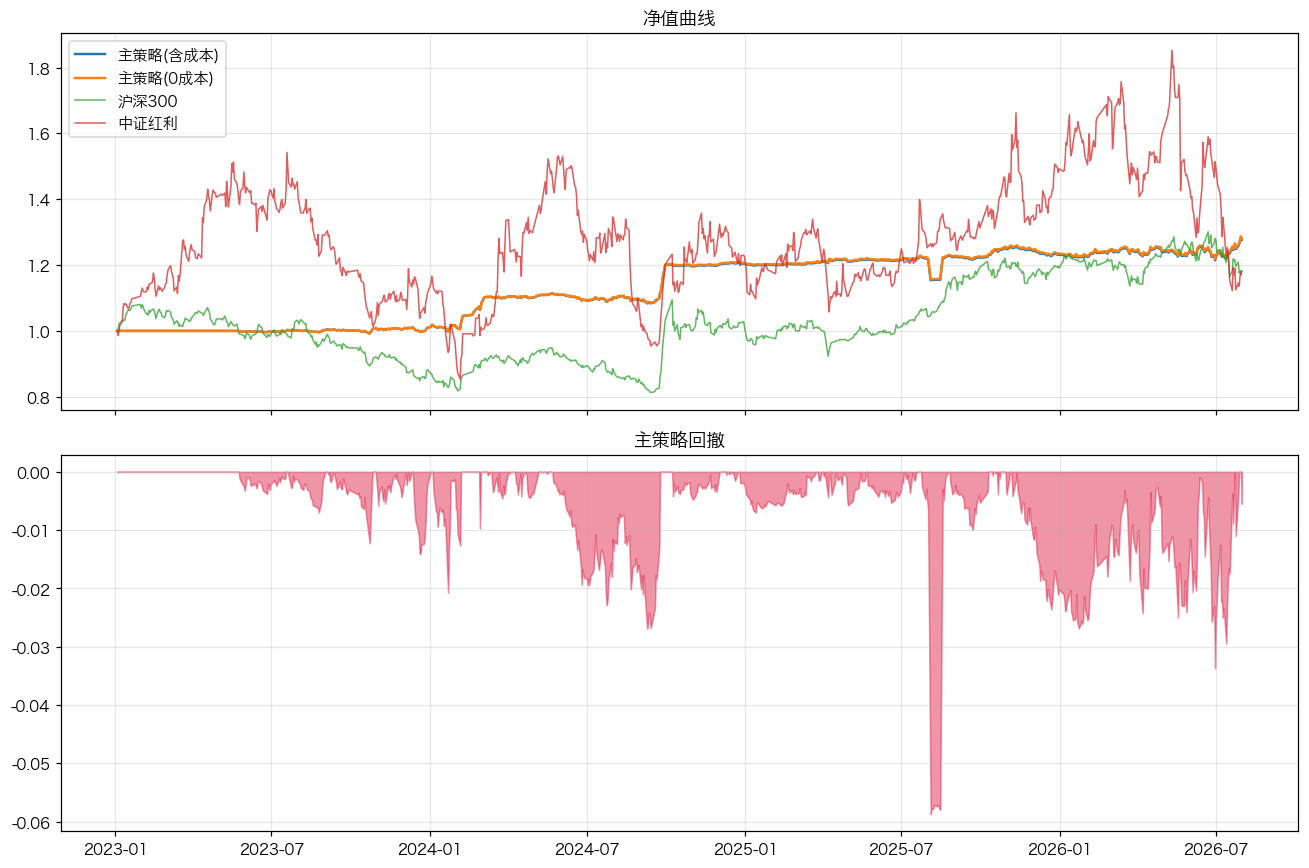

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for label, n in navs.items():
    lw = 1.6 if label.startswith('主策略') else 1.0
    axes[0].plot(n.index, n.values, label=label, lw=lw, alpha=1 if label.startswith('主策略') else 0.75)
axes[0].set_title('净值曲线'); axes[0].legend(); axes[0].grid(alpha=.3)
roll = eq['nav'].expanding().max()
axes[1].fill_between(eq.index, eq['nav']/roll-1, 0, color='crimson', alpha=.45)
axes[1].set_title('主策略回撤'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3.1 阶梯成因: 净值 × 持仓段对照

上图看起来很"阶梯"——原因: 策略平均仓位只有 ~20%, 平时净值一天只动 0.1% 左右(90% 在现金上磨), 踏板平缓; 而当**多只持仓同一天齐涨**(如 2024-09 的行情), 5~10% 权重 × 5~9% 涨幅=净值一次性跳 4~6.7%。下面把持仓市值画成背景, 并标注最大跳升日来验证。

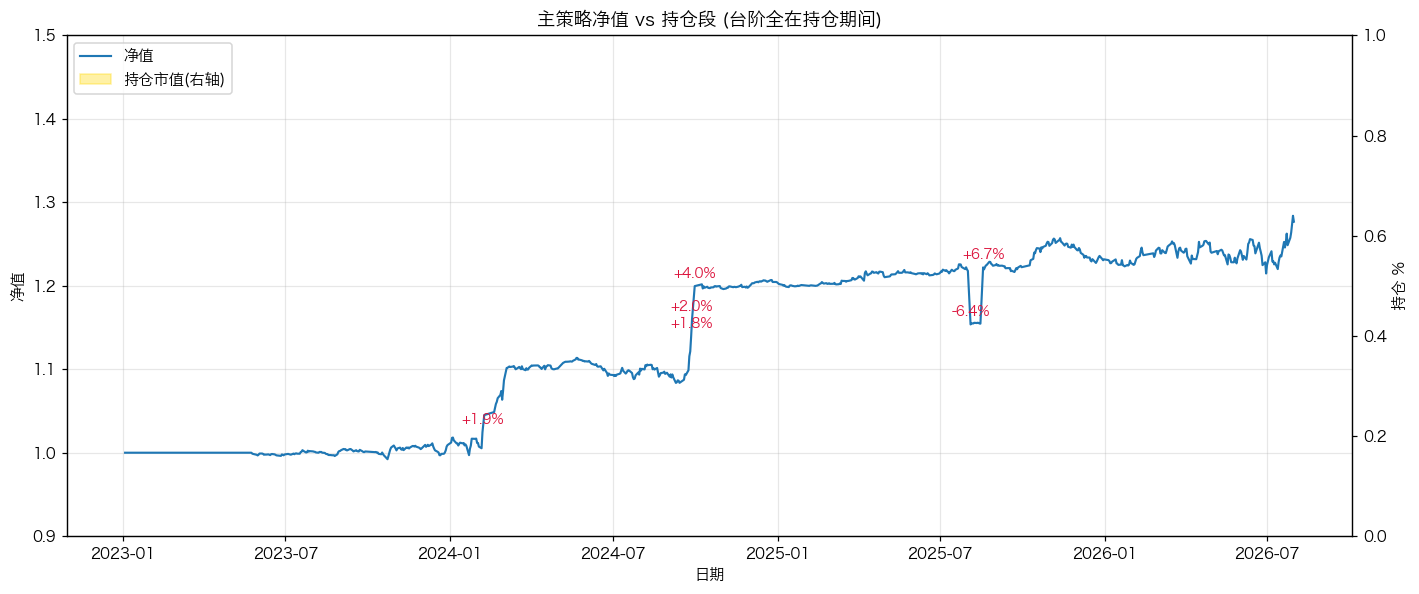

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(eq.index, eq['nav']/500000, color='tab:blue', lw=1.4, label='净值')
ax.fill_between(eq.index, 0, eq['exposure'], color='gold', alpha=.35, label='持仓市值(右轴)')
ax.set_ylabel('净值'); ax.set_xlabel('日期'); ax.grid(alpha=.3)
ax.set_ylim(0.9, 1.5)
ax2 = ax.twinx(); ax2.set_ylim(0, 1); ax2.set_ylabel('持仓 %'); ax2.grid(False)
ax.legend(loc='upper left'); ax.set_title('主策略净值 vs 持仓段 (台阶全在持仓期间)')

dchg = eq['nav'].diff()
top = dchg.abs().sort_values(ascending=False).head(6).index
for d in top:
    ax.annotate(f'{dchg[d]/500000*100:+.1f}%', (d, eq.loc[d,'nav']/500000+0.01),
                fontsize=9, color='crimson', ha='center')
plt.tight_layout(); plt.show()

## 4. 仓位与交易分析

In [7]:
print('组合仓位(exposure)统计:')
print(eq['exposure'].describe().round(3).to_string())
print('\n年度平均仓位:')
print(eq['exposure'].resample('YE').mean().round(3).to_string())

组合仓位(exposure)统计:
count    866.000
mean       0.177
std        0.133
min        0.000
25%        0.049
50%        0.155
75%        0.292
max        0.484

年度平均仓位:
date
2023-12-31    0.084
2024-12-31    0.179
2025-12-31    0.161
2026-12-31    0.364
Freq: YE-DEC


In [8]:
t = pd.DataFrame(bt.trades)
t['date'] = pd.to_datetime(t['date'])
t['name'] = t['code'].map(POOL)
buy = t[t.action == 'buy']; sell = t[t.action == 'sell']
print(f'成交笔数: 买入 {len(buy)}, 卖出 {len(sell)}')
print('\n入场/补仓原因分布:')
print(buy['reason'].str.split(' ').str[0].value_counts().to_string())
print('\n买入次数 Top10 标的:')
print(buy.groupby(['code', 'name']).size().sort_values(ascending=False).head(10).to_string())
print('\n持有过不同标的数:', buy['code'].nunique(), f'/ {len(POOL)}')

成交笔数: 买入 33, 卖出 19

入场/补仓原因分布:
reason
入场         27
补仓(-20%     4
补仓(-10%     2

买入次数 Top10 标的:
code    name
603508  思维列控    4
000048  京基智农    3
600096  云天化     3
601766  中国中车    2
600377  宁沪高速    2
000895  双汇发展    2
600273  嘉化能源    2
600023  浙能电力    2
600012  皖通高速    2
301004  嘉益股份    2

持有过不同标的数: 19 / 28


In [9]:
buy[buy.reason.str.startswith('入场')].sort_values(['code','date'])[['date','code','name','shares','price','reason']].head(15)

,date,code,name,shares,price,reason
2,2023-10-16,000048,京基智农,1500,16.338165,入场 股息率5.7% PE-32.3 偏差-12.8%
45,2026-05-28,000048,京基智农,2400,12.666330,入场 股息率3.0% PE-35.3 偏差-22.2%
17,2024-07-08,000895,双汇发展,1300,20.640315,入场 股息率3.0% PE14.1 偏差-13.0%
50,2026-06-18,000895,双汇发展,1300,22.801395,入场 股息率3.5% PE15.0 偏差-12.6%
18,2024-07-10,000937,冀中能源,5600,4.852425,入场 股息率9.8% PE3.5 偏差-14.6%
38,2025-09-26,301004,嘉益股份,500,59.029500,入场 股息率5.0% PE12.1 偏差-12.1%
35,2025-09-02,600012,皖通高速,2200,13.866930,入场 股息率4.2% PE12.6 偏差-12.4%
4,2023-10-23,600023,浙能电力,6900,3.551775,入场 股息率5.5% PE-18.9 偏差-12.4%
30,2024-11-25,600023,浙能电力,6100,4.862430,入场 股息率4.6% PE19.8 偏差-15.0%
5,2023-12-05,600036,招商银行,1000,23.601795,入场 股息率6.3% PE5.0 偏差-13.6%


## 5. 交易明细(逐笔)

In [10]:
t.sort_values(['date','code']).reset_index(drop=True)[['date','code','name','action','shares','price','reason']]

,date,code,name,action,shares,price,reason
0,2023-05-24,600096,云天化,buy,1600,15.347670,入场 股息率5.6% PE6.9 偏差-12.5%
1,2023-08-25,603508,思维列控,buy,1900,12.606300,入场 股息率3.7% PE17.9 偏差-13.0%
2,2023-10-16,000048,京基智农,buy,1500,16.338165,入场 股息率5.7% PE-32.3 偏差-12.8%
3,2023-10-19,601766,中国中车,buy,5000,4.942470,入场 股息率3.7% PE16.4 偏差-13.3%
4,2023-10-23,600023,浙能电力,buy,6900,3.551775,入场 股息率5.5% PE-18.9 偏差-12.4%
5,2023-12-05,600036,招商银行,buy,1000,23.601795,入场 股息率6.3% PE5.0 偏差-13.6%
6,2023-12-18,600096,云天化,buy,2400,12.226110,补仓(-20% 成本15.34)
7,2024-01-04,600023,浙能电力,sell,6900,4.347825,卖出 dev=10.3%
8,2024-02-05,601233,桐昆股份,buy,2300,10.725360,入场 股息率3.0% PE8.1 偏差-22.8%
9,2024-02-05,603508,思维列控,buy,3400,9.394695,补仓(-20% 成本12.60)


## 5.1 持仓阶段个股走势

对每只被持有过的标的, 一张图横向铺满, 画出入场→清仓的完整区间, 并在**图首补齐开仓前约 200 个交易日**好让 MA120 及触发带覆盖整张图。绿点=买入(入场/补仓), 红叉=卖出。

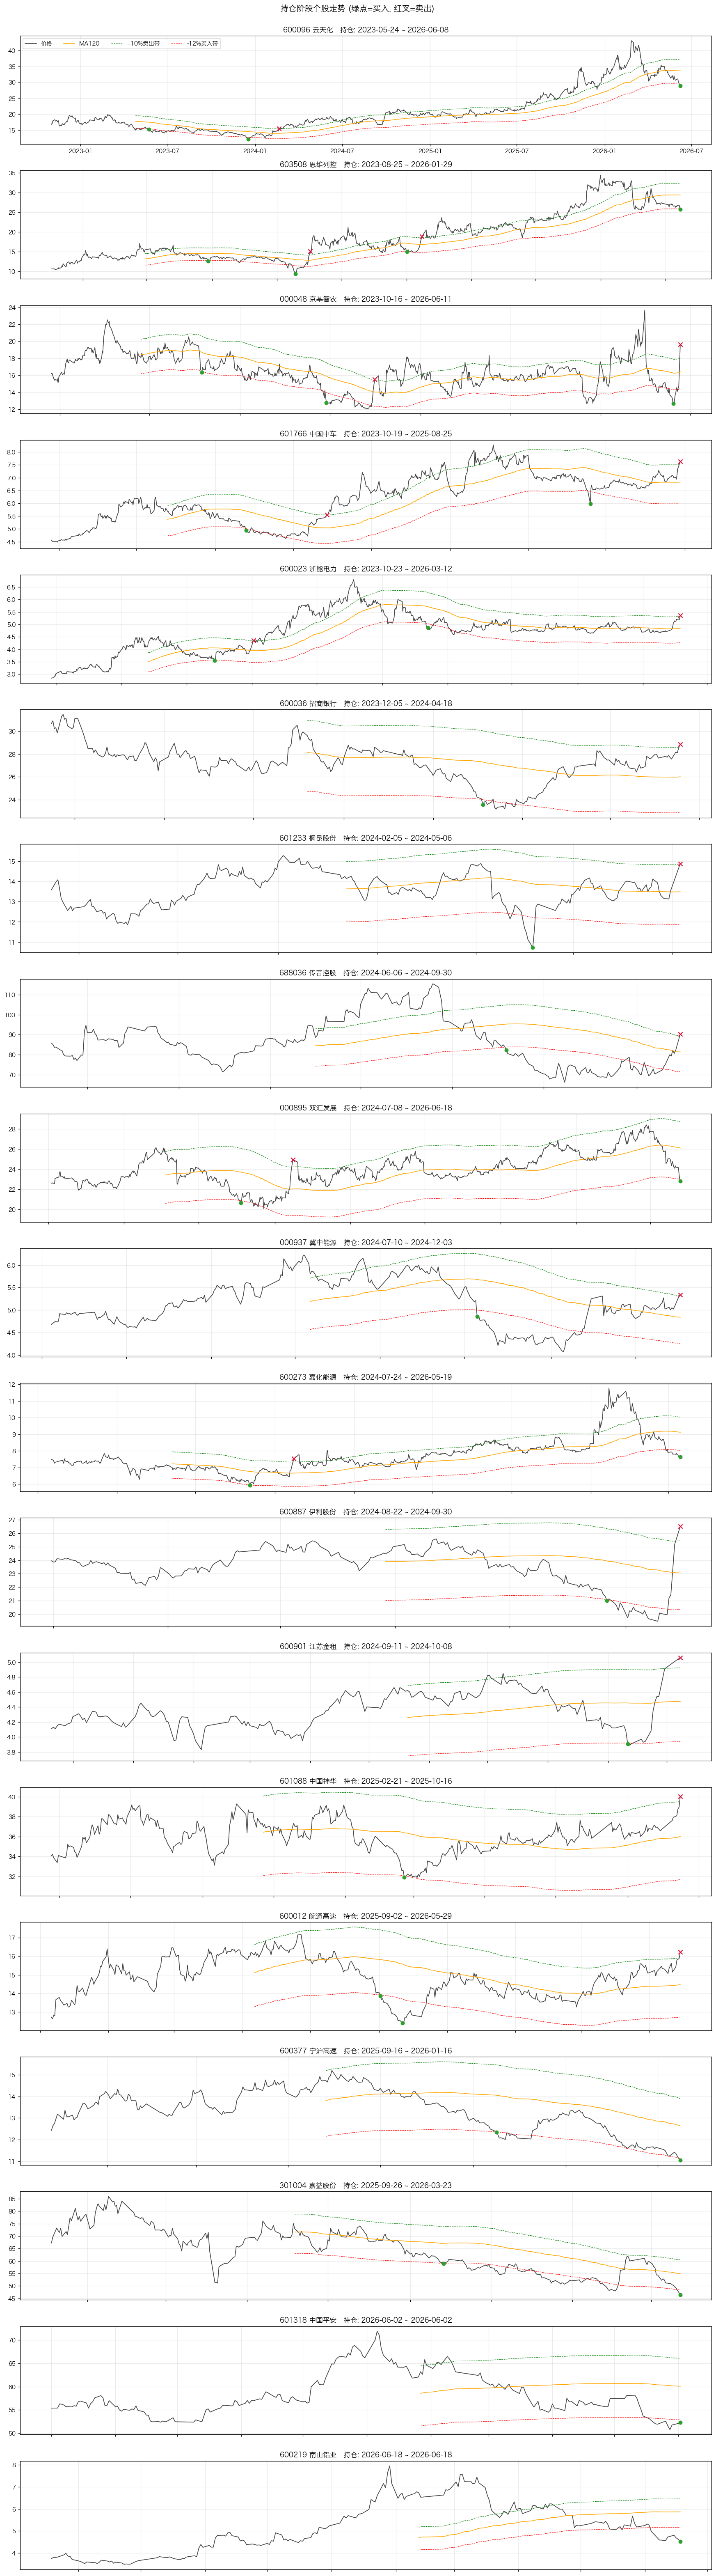

In [11]:
from strategy.band_ma120 import MA_WINDOW

codes = sorted(set(t[t.action == 'buy']['code']), key=lambda c: t[t.code == c]['date'].iloc[0])
fig, axes = plt.subplots(len(codes), 1, figsize=(16, 3.0 * len(codes)), squeeze=False)
PREPEND = 200

for i, cod in enumerate(codes):
    ax = axes[i][0]
    df = mkt[cod]
    tt = t[t.code == cod]
    buys = tt[tt.action == 'buy']
    sells = tt[tt.action == 'sell']
    d0 = buys['date'].iloc[0]
    d1 = buys['date'].iloc[-1]
    if len(sells):
        d1 = max(d1, sells['date'].iloc[-1])
    hist = df[df.index <= d0]
    win = df.loc[hist.index[-min(PREPEND, len(hist))]:]
    win = win[win.index <= d1]
    ax.plot(win.index, win['close'], lw=1.1, color='#444', label='价格')
    ma = win['close'].rolling(MA_WINDOW).mean()
    ax.plot(win.index, ma, lw=1.0, color='orange', label='MA120')
    base = ma.dropna()
    ax.plot(base.index, base * 1.10, lw=.7, ls='--', color='green', label='+10%卖出带')
    ax.plot(base.index, base * 0.88, lw=.7, ls='--', color='red', label='-12%买入带')
    for _, r in buys.iterrows():
        if r['date'] in df.index:
            ax.scatter(r['date'], df.loc[r['date'], 'close'], marker='o', s=30, color='tab:green', zorder=5)
    for _, r in sells.iterrows():
        if r['date'] in df.index:
            ax.scatter(r['date'], df.loc[r['date'], 'close'], marker='x', s=45, color='crimson', zorder=5)
    ax.set_title(f"{cod} {POOL.get(cod, '')}   持仓: {d0.date()} ~ {d1.date()}", fontsize=11)
    ax.grid(alpha=.25)
    ax.tick_params(labelsize=9)
    if i > 0:
        ax.set_xticklabels([])

axes[0][0].legend(loc='upper left', ncol=4, fontsize=9)
fig.suptitle('持仓阶段个股走势 (绿点=买入, 红叉=卖出)', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

## 6. 参数敏感性 (入场带 × 卖出带 → 年化)

In [12]:
rows = []
for dev_buy in [-0.10, -0.12, -0.15]:
    for dev_sell in [0.08, 0.10, 0.12]:
        scr = build_pool_screener(div_min=0.03, pe_max=20.0, dev_buy=dev_buy)
        b = BandStrategy(mkt, scr, initial_capital=INITIAL_CAPITAL, with_cost=True)
        b.dev_sell = dev_sell
        n = b.run(START, END)['nav'] / INITIAL_CAPITAL
        s = perf_summary(n)
        rows.append({'入场带': f'{dev_buy:.0%}', '卖出带': f'{dev_sell:.0%}',
                     '年化': s['annual_return'], 'Sharpe': s['sharpe'],
                     '最大回撤': s['max_drawdown'], '交易数': len(b.trades)})
pd.DataFrame(rows).pivot_table(index='入场带', columns='卖出带', values='年化', aggfunc='first')

卖出带,10%,12%,8%
入场带,,,
-10%,6.87%,7.79%,7.91%
-12%,7.08%,7.63%,7.41%
-15%,4.00%,4.15%,3.55%
